In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

### Pure validation (avoid data leakage caused by clustering)

In [2]:
features = ['Cirrus_weighted', 'Cirrostratus_weighted', 'Stratus_weighted', 'Stratocumulus_weighted',
            'Cumulus_weighted', 'Cirrocumulus_weighted', 'Nimbus_weighted', 'Clear_weighted',
            'Absolute_Humidity(g/m^3)', 'label']
target = 'Radiation Value'

train_df = pd.read_csv("img_attribute_train.csv")
train_df = train_df.dropna()

X_train, y_train = train_df[features], train_df[target]
X_train.columns = X_train.columns.str.replace('_weighted', '')
X_train.columns = X_train.columns.str.replace('label', 'Cluster', regex=False)
X_train.columns = X_train.columns.str.replace('Absolute_Humidity(g/m^3)', 'AbsHumidity', regex=False)

valid_df = pd.read_csv('img_attribute_valid.csv')
valid_df = valid_df.dropna()

X_valid, y_valid = valid_df[features], valid_df[target]
X_valid.columns = X_valid.columns.str.replace('_weighted', '')
X_valid.columns = X_valid.columns.str.replace('label', 'Cluster', regex=False)
X_valid.columns = X_valid.columns.str.replace('Absolute_Humidity(g/m^3)', 'AbsHumidity', regex=False)

### Hyperparameter tuning with Grid Search
model = XGBRegressor(random_state=42, n_jobs=1)

param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [200, 300],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,  # Grid Search CV folds
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

### Evaluate on validation set
y_pred = best_model.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"R² on validation set: {r2:.4f}")
print(f"RMSE on validation set: {rmse:.4f}")

R² on validation set: 0.9044
RMSE on validation set: 2.9422


### 5-fold validation on full dataset (to observe the overall trend)

In [3]:
df = pd.read_csv("img_attribute.csv")
df = df.dropna()

features = ['Cirrus_weighted', 'Cirrostratus_weighted', 'Stratus_weighted', 'Stratocumulus_weighted',
            'Cumulus_weighted', 'Cirrocumulus_weighted', 'Nimbus_weighted', 'Clear_weighted',
            'Absolute_Humidity(g/m^3)', 'label']

target = 'Radiation Value'
X, y = df[features], df[target]
X.columns = X.columns.str.replace('_weighted', '')
X.columns = X.columns.str.replace('label', 'Cluster', regex=False)
X.columns = X.columns.str.replace('Absolute_Humidity(g/m^3)', 'AbsHumidity', regex=False)

In [4]:
model = XGBRegressor(random_state=42, n_jobs=1)

param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [200, 300],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,  # Grid Search CV folds
    n_jobs=-1
)

grid_search.fit(X, y)
best_model = grid_search.best_estimator_

In [5]:
print("Best Parameters:", end="")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}", end=",")

Best Parameters:  colsample_bytree: 0.8,  learning_rate: 0.1,  max_depth: 4,  n_estimators: 200,  subsample: 0.8,

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
rmse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # use the best parameters to retrain on the current fold's training data
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print(f"Average R²:   {np.mean(r2_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")
print(r2_scores)

Average R²:   0.9054
Average RMSE: 2.9436
[0.9032515190221654, 0.9058826341091919, 0.9065975778881961, 0.9082025649585594, 0.9029743293247743]


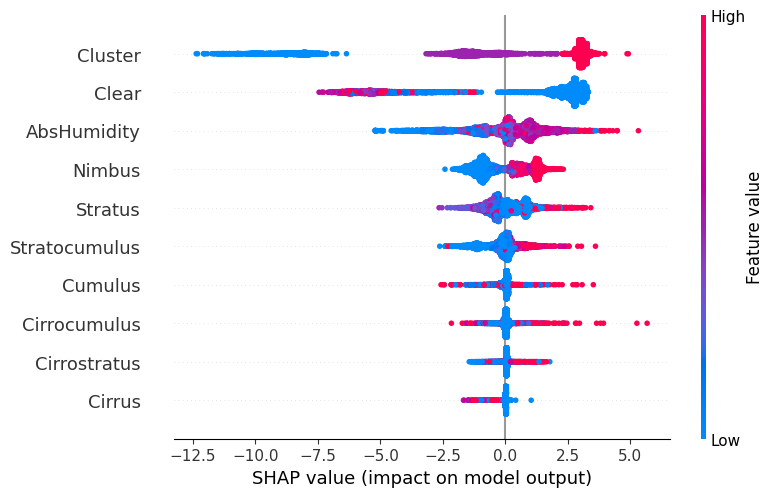

In [7]:
best_model.fit(X, y)
explainer = shap.Explainer(best_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values)
plt.show()

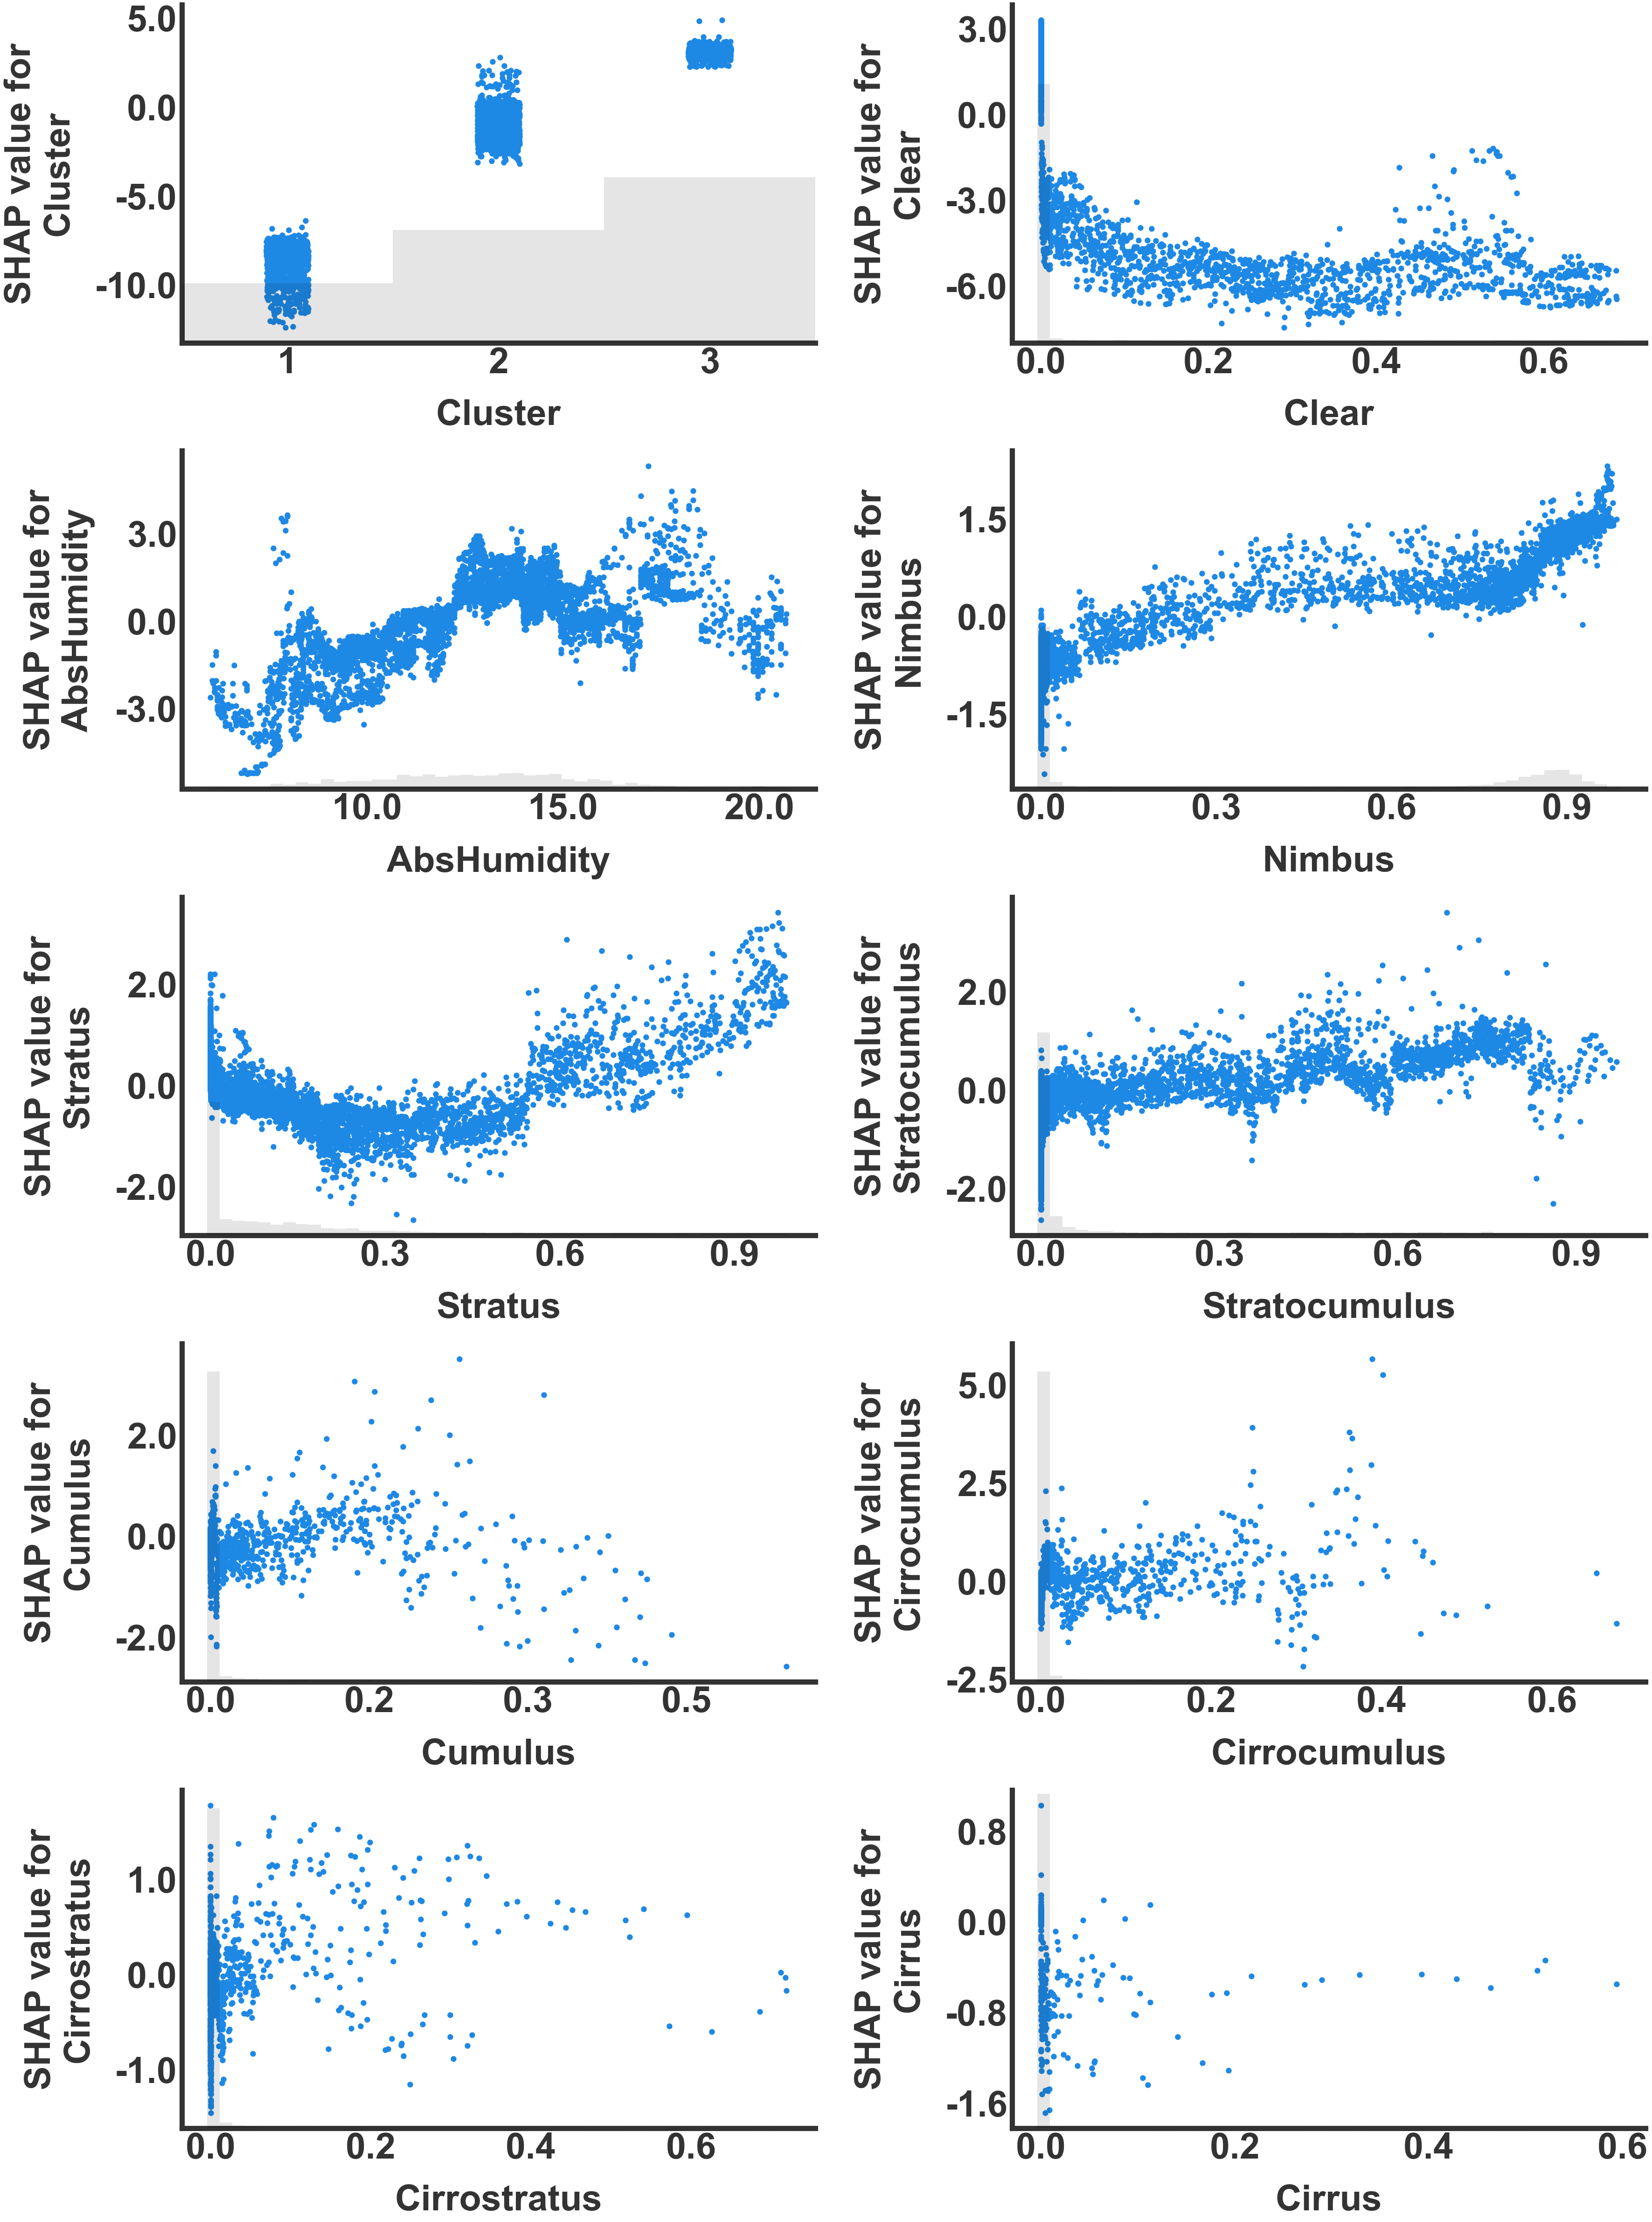

In [8]:
# Calculating the mean absolute SHAP values for each feature to determine importance
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = X.columns[sorted_idx]

num_features = len(sorted_features)
features_to_plot = sorted_features[:num_features]

nrows, ncols = 5, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(36, 48))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    shap.plots.scatter(shap_values[:, feature], ax=axes[i], show=False, dot_size=80)

    axes[i].xaxis.set_major_locator(MaxNLocator(nbins=4))
    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))

    if i == 0:
        axes[i].xaxis.set_major_formatter(FormatStrFormatter('%d'))  # revise x_label to 1, 2, 3
        axes[i].set_xticks([1, 2, 3])  # set x ticks to 1, 2, 3
    else:
        axes[i].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    axes[i].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    for label in axes[i].get_xticklabels():
        label.set_fontsize(56)
        label.set_fontfamily('Arial')
        label.set_fontweight('bold')
    for label in axes[i].get_yticklabels():
        label.set_fontsize(56)
        label.set_fontfamily('Arial')
        label.set_fontweight('bold')
    axes[i].xaxis.label.set_size(56)
    axes[i].xaxis.label.set_fontfamily('Arial')
    axes[i].xaxis.label.set_weight('bold')
    axes[i].yaxis.label.set_size(56)
    axes[i].yaxis.label.set_fontfamily('Arial')
    axes[i].yaxis.label.set_weight('bold')
    axes[i].xaxis.labelpad = 30
    axes[i].yaxis.labelpad = 30

    for spine in axes[i].spines.values():
        spine.set_linewidth(8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(wspace=50, hspace=50)
plt.tight_layout()
plt.show()

In [9]:
shap_values.base_values[0]

-10.000221

In [10]:
# df_test = pd.read_csv("img_attribute.csv")
df_test = pd.read_csv("img_attribute_case.csv")
df_test = df_test.dropna()

features = ['Cirrus_weighted', 'Cirrostratus_weighted', 'Stratus_weighted', 'Stratocumulus_weighted',
            'Cumulus_weighted', 'Cirrocumulus_weighted', 'Nimbus_weighted', 'Clear_weighted',
            'Absolute_Humidity(g/m^3)', 'label']

target = 'Radiation Value'
X_test, y_test = df_test[features], df_test[target]
X_test.columns = X_test.columns.str.replace('_weighted', '')
X_test.columns = X_test.columns.str.replace('label', 'Cluster', regex=False)
X_test.columns = X_test.columns.str.replace('Absolute_Humidity(g/m^3)', 'AbsHumidity', regex=False)
y_pred = best_model.predict(X_test)
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Test R²:   0.8396
Test RMSE: 4.3181


In [11]:
x, y = y_pred, y_test

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=x, y=y,
        mode='markers',
        marker=dict(size=15, opacity=0.6, color='#2a9d8f'),
        # marker=dict(size=15, opacity=0.6, color='#39BCBC'),
        name='Data',
        showlegend=False
    )
)

fig.add_trace(
    go.Scatter(
        x=[-40, 5], y=[-40, 5],
        mode='lines',
        line=dict(color='Gray', width=10),
        showlegend=False
    )
)

fig.add_annotation(
    x=3, y=1,
    text="x = y",
    showarrow=False,
    font=dict(size=56, weight='bold', family="Arial", color="gray"),
    textangle=-45
)

fig.add_annotation(
    x=0.03, y=0.99,
    xref="paper", yref="paper",
    text="b)",
    showarrow=False,
    font=dict(size=70, weight='bold', family="Arial", color="black"),
    xanchor="left",
    yanchor="top"
)

fig.update_layout(
    height=1200,
    width=1400,
    xaxis = dict(
        title = dict(text='Predicted', standoff=30),
        tickfont=dict(size=56, family='Arial', weight='bold'),
        titlefont=dict(size=64, family='Arial', weight='bold'),
        linewidth=6, linecolor='black',
        range=[-40, 5],
        tickwidth=6, ticklen=15
    ),
    yaxis = dict(
        title = dict(text='Ground Truth', standoff=30),
        tickfont=dict(size=56, family='Arial', weight='bold'),
        titlefont=dict(size=64, family='Arial', weight='bold'),
        linewidth=6, linecolor='black',
        range=[-40, 5],
        tickwidth=6, ticklen=15
    ),
    margin=dict(t=10, b=180, l=220, r=10),
    template='simple_white'
)

fig.show()

### Residual

In [12]:
df_test['Predicted'] = y_pred
df_test['Residual'] = (df_test[target] - df_test['Predicted'])

In [13]:
# Calculate daily averages for Actual, Predicted, and Residual
required_cols = {'Year','Month','Day', target, 'Predicted', 'Residual'}
daily = (df_test.groupby(['Year','Month','Day'], as_index=False)
         .agg({target:'mean', 'Predicted':'mean', 'Residual':'mean'}))
daily = daily.rename(columns={target: 'Actual'})

daily['Date'] = pd.to_datetime(daily[['Year','Month','Day']])
daily = daily.sort_values('Date').reset_index(drop=True)
full_dates = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
daily = (daily.set_index('Date').reindex(full_dates).rename_axis('Date').reset_index())

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Residual'], mode='lines+markers',
                         name='Residual', line=dict(color='#5f9ea0', width=10), 
                         marker=dict(size=25), connectgaps=False)) #39BCBC

fig.add_shape(type="line", x0=daily['Date'].min(), x1=daily['Date'].max(), y0=5, y1=5,
              line=dict(color="gray", width=4, dash="dash"))
fig.add_shape(type="line", x0=daily['Date'].min(), x1=daily['Date'].max(), y0=-5, y1=-5,
              line=dict(color="gray", width=4, dash="dash"))

if daily['Date'].notna().any():
    x_min = daily['Date'].min()
    x_max = daily['Date'].max()
    span = x_max - x_min
    pad = span * 0.02  # 2% padding
    fig.update_xaxes(range=[x_min - pad, x_max + pad])
    fig.update_yaxes(range=[daily['Residual'].min() - 3, daily['Residual'].max() + 3])

fig.update_xaxes(nticks=10)
fig.update_yaxes(nticks=5)

fig.update_layout(
    xaxis=dict(title=dict(text='Date', font=dict(size=64, family='Arial', weight='bold'), standoff=40), tickformat="%m/%d", tickwidth=6, ticklen=15),
    yaxis=dict(title=dict(text='Residual', font=dict(size=64, family='Arial', weight='bold'), standoff=40), tickwidth=6, ticklen=15),
    template='simple_white',
    margin=dict(l=70, r=20, t=10, b=50),
    height=800, width=2000
)

fig.update_xaxes(tickfont=dict(size=64, family='Arial', weight='bold'), linewidth=6, linecolor='black')
fig.update_yaxes(tickfont=dict(size=64, family='Arial', weight='bold'), linewidth=6, linecolor='black')

fig.show()

In [15]:
# 輸出 Residual 到 CSV
# cloud_cols = [
#     'Clear_weighted', 'Cirrus_weighted', 'Cirrostratus_weighted', 'Stratus_weighted', 
#     'Stratocumulus_weighted', 'Cumulus_weighted', 'Cirrocumulus_weighted', 'Nimbus_weighted'
# ]
# agg_dict = {target: 'mean', 'Predicted': 'mean', 'Residual': 'mean'}
# for col in cloud_cols:
#     agg_dict[col] = 'mean'

# daily = (df_test.groupby(['Year','Month','Day'], as_index=False)
#          .agg(agg_dict))
# daily = daily.rename(columns={target: 'Actual'})
# daily.to_csv("residuals_daily.csv", index=False)